# 펭귄을 다시 꺼내서...

### penguins = sns.load_dataset("penguins")

- 1) 결측치 확인 -> 전처리
- 2) 수치형 변수만 선택해 상관분석
- 3) bill_length를 카테고리로 나눠 분석
- 4) 히트맵 그리기
- 5) hue 사용해서 그룹 간 시각화
- 6) catplot 이용해 그래프 그리고 해석

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
penguins = sns.load_dataset("penguins")
penguins.info()
penguins.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [4]:
#결측값 있는 것 찾아서 중앙값으로 변경
penguins["bill_length_mm"] = penguins["bill_length_mm"].fillna(penguins["bill_length_mm"].median())
penguins["bill_depth_mm"] = penguins["bill_depth_mm"].fillna(penguins["bill_depth_mm"].median())
penguins["flipper_length_mm"] = penguins["flipper_length_mm"].fillna(penguins["flipper_length_mm"].median())
penguins["body_mass_g"] = penguins["body_mass_g"].fillna(penguins["body_mass_g"].median())

#결측치 행 제거
penguins.dropna(subset=["sex"], inplace=True)

#확인
penguins.info()
penguins.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [5]:
#상관분석: 수치형 변수만 선택
peng = penguins.select_dtypes(include=[int, float]) 
peng.shape
peng.head()

peng_corr = peng.corr(method = 'pearson')
peng_corr

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


In [6]:
#카테고리화: 59.6(최대) ~ 44.5(중앙) ~ 32.1(최소)
def bill_length(x):
    if x < 35:
        return 0
    elif x < 40:
        return 1
    elif x < 45:
        return 2
    elif x < 50:
        return 3
    elif x < 55:
        return 4
    else:
        return 5

In [7]:
#bill_length를 카테고리로 나눠 분석
penguins["bill_lengths"] = penguins["bill_length_mm"].apply(bill_length)

penguins['sex_num'] = penguins['sex'].map({'Male':1, 'Female':0})
penguins['species_num'] = penguins['species'].map({'Adelie':0, 'Chinstrap':1, 'Gentoo':2})
penguins['island_num'] = penguins['island'].map({'Torgersen':0, 'Dream':1, 'Biscoe':2})

penguins #확인

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_lengths,sex_num,species_num,island_num
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,1,1,0,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,1,0,0,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,2,0,0,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,1,0,0,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female,3,0,2,2
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,3,0,2,2
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,4,1,2,2
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,3,0,2,2


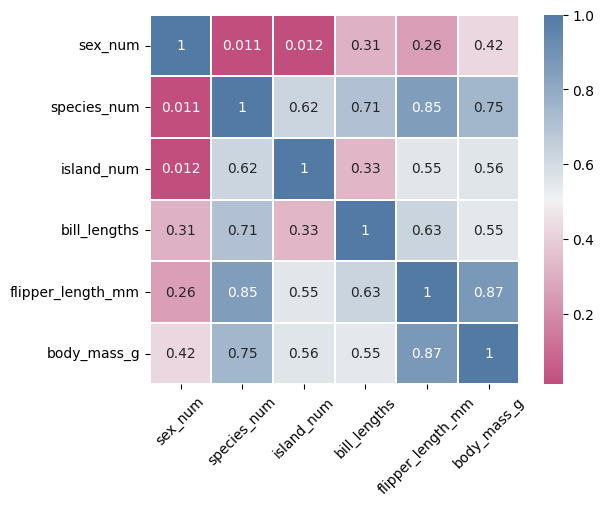

In [8]:
#히트맵 그리기
heatmap_data = penguins[['sex_num', 'species_num', 'island_num', 'bill_lengths','flipper_length_mm','body_mass_g']]

# colormap = plt.cm.RdBu
colormap = sns.diverging_palette(350, 245, s=60, as_cmap=True)

sns.heatmap(heatmap_data.astype(float).corr(), linewidths = 0.1, vmax = 1.0, square = True, cmap = colormap, linecolor = 'white', annot = True, annot_kws = {"size": 10})
plt.xticks(rotation = 45, fontsize = 10)
plt.show()

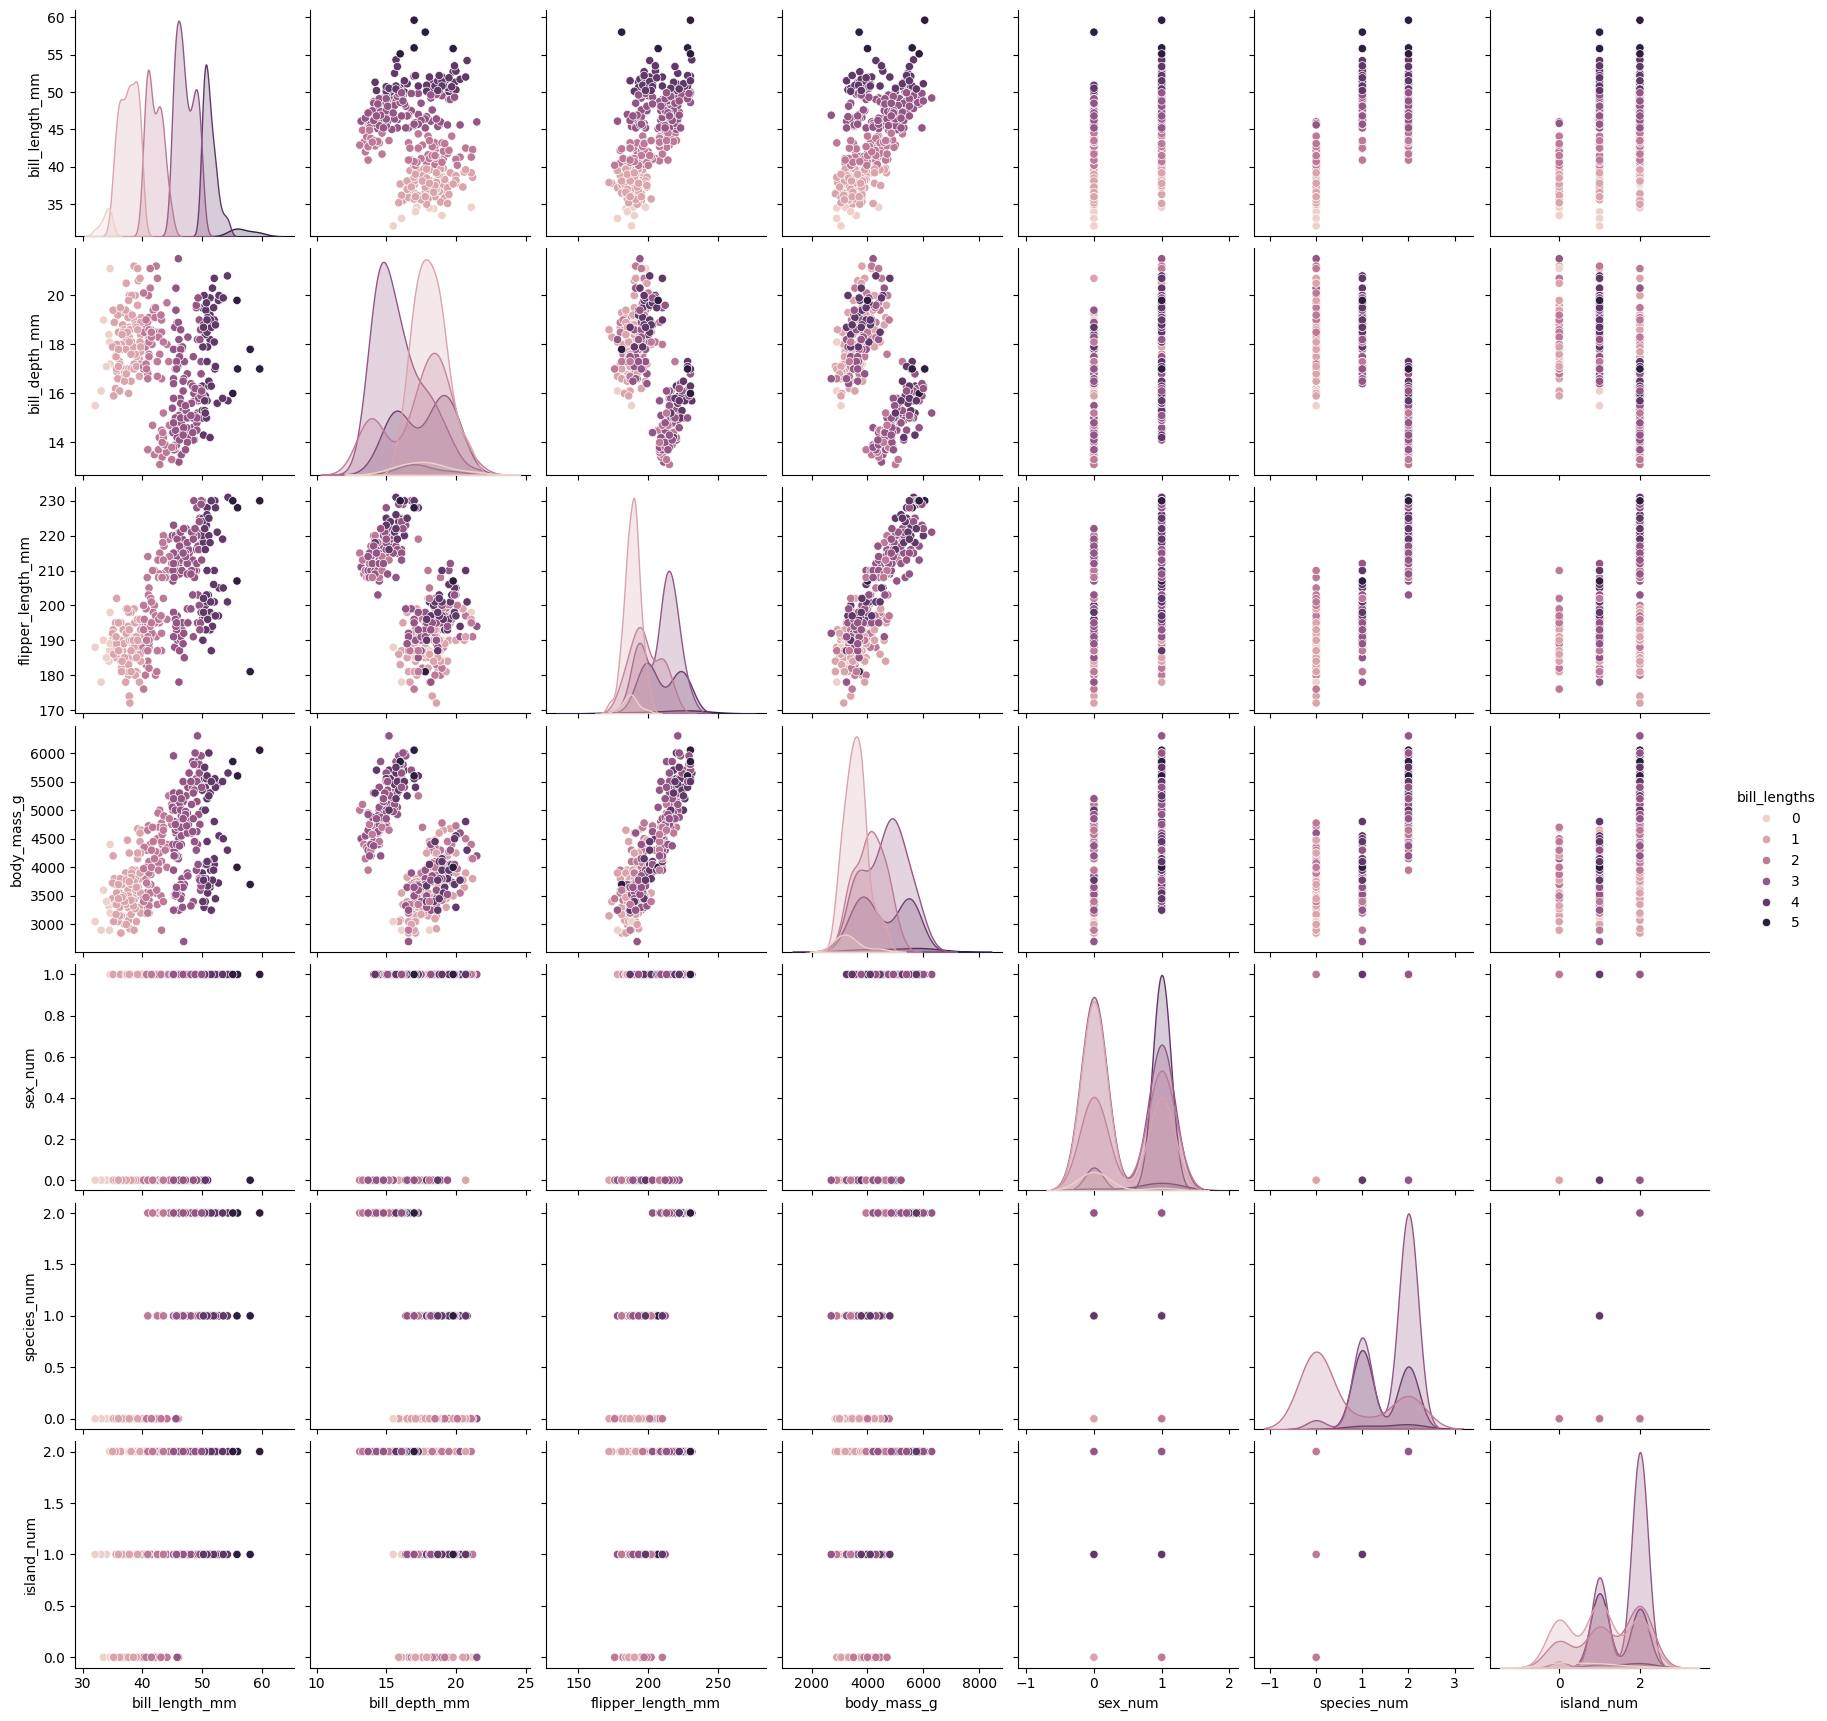

In [9]:
#시각화
sns.pairplot(penguins, hue = 'bill_lengths')
plt.show()

## 히트맵 모든 변수에 대한 그래프 비교

#### hue: bill_length로 설정

- 점 색깔: 옅은 색에서 짙은 색으로 갈수록 카테고리에 의해 부리 길이 길어지는 경향
- 부리 길이가 길어질수록 부리 높이도 높아지고, 무게도 많이 나가고, 날개 길이도 길어지는 편.

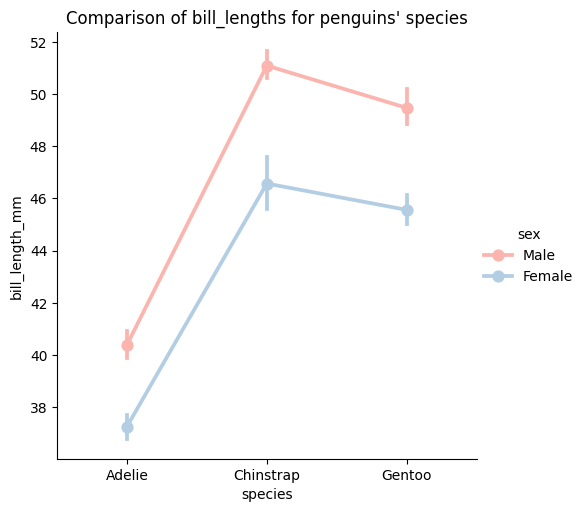

In [10]:
sns.catplot(x = 'species', y = 'bill_length_mm', hue = 'sex', data = penguins, kind = 'point', palette='Pastel1') #hue: 어떤 것을 기준으로 카운트할 지를 결정
plt.title('Comparison of bill_lengths for penguins\' species')
plt.show()

## 펭귄 종별 부리 길이 비교
#### 기본
- hue: 성별
- point 식으로 표현하여 성별별 범위 설명(세로 막대)
- 색깔: 팔레트에서 파스텔1 선택

#### 경향성
- 아델리가 부리가 가장 작은 편 -> 몸집 자체도 작을 것으로 추정
- 신스트랩과 젠투 모두 5cm에 육박하는 부리 길이 지님
- 신스트랩이 부리 길이 가장 김 -> 몸집 가장 클 것으로 추정
- 대체로 남성체들(핑크)이 여성체들(블루)보다 그래프가 우위 -> 부리 자체는 남성체쪽이 더 큰 편